# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
# NOTE: this is no needed for Google Collab
#!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [50]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# disable warnings
warnings.filterwarnings("ignore")

### Understanding the structure of the data

In [51]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')
# let colab access my google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
# Write your code here to read the data
data = pd.read_csv('/content/drive/My Drive/foodhub_order.csv')

In [53]:
# Write your code here to view the first 5 rows
data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


Observations: The dataframe has 9 columns. This data represents orders placed by customers. There are column fields customer id and order id, that are generated fields that uniquely identify the customers and orders.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [54]:
# Write your code here
print(f'There are', data.shape[0], 'rows and', data.shape[1], 'columns in the data for FoodHub.')
print(f'Output of data.shape tuple for dataframe food hub is:', data.shape, f'.')

There are 1898 rows and 9 columns in the data for FoodHub.
Output of data.shape tuple for dataframe food hub is: (1898, 9) .


#### Observations: The data has 1898 rows and 9 columns which are customer orders in FoodHub.  This data is observed by using the data.shape command which is part of the python pandas library for dataframes - pandas.DataFrame.shape.


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [55]:
# Write your code here
print(64 * "*")
print("Output of data.info() for data for FootHub is: ")
print(64 * "*")
data.info()
print(72 * "*")

****************************************************************
Output of data.info() for data for FootHub is: 
****************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB
************************************************************************


# Write your comments here
####Observations:
There are 9 columns observed in the FoodHub dataframe. It is observed that 4 columns are object type: restaurant_name, cuisine_type, day_of_the_week and rating. It is observed that 4 columns are int64 type: order_id, customer_id, food_prepartion_time, and delivery-time. It is observed that 1 column is float64: cost_of_the_order.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [56]:
# Write your code here
# check null values
print(f'Print null values for all columns in data frame')
print(data.isnull().sum())
print

Print null values for all columns in data frame
order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64


<function print>

#### Observations: There is no missing values in the FoodHub dataframe. All columns have 1898 entries and no null values. The above calculation using sum and isnull confirms no  rows are null in the dataframe.  No treatment of data is necessary. For ratings some customers choose not to give ratings and this is implemented by using term "Not given" in lieu of a numeric rating.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [57]:
# Write your code here
data.describe().T


,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


#### Observations:
The statistical summary is observed by using the dataframe describe pandas.DataFrame.describe command. We observe the mean min max std and 25% 50% 75% for the columns cost_of_the_order, food_prepartion_time and delivery-time are relavent calculations and can be used in the future for comparitive analysis.
We have 1898 observations, 25% of the observations cost 12.08 or below, take about 23 minutes or below to prepare, and 20 minutes or below to deliver, 50% have values below 14.14,27, and 25 for the cost, preparation time, & delivery time respectively, for the 75% we have values below 22.29, 31, & 28 with the max observations being 35.41, 35 and 33 for the same parameters.
Of these it takes a minimum of 20 minutes, an average of 27.37 minutes and a maximum of 35 minutes to prepare the food once the order is placed.

### **Question 5:** How many orders are not rated? [1 mark]

************************************************************************
rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64
************************************************************************
Bar chart for column rating in data frame:
************************************************************************


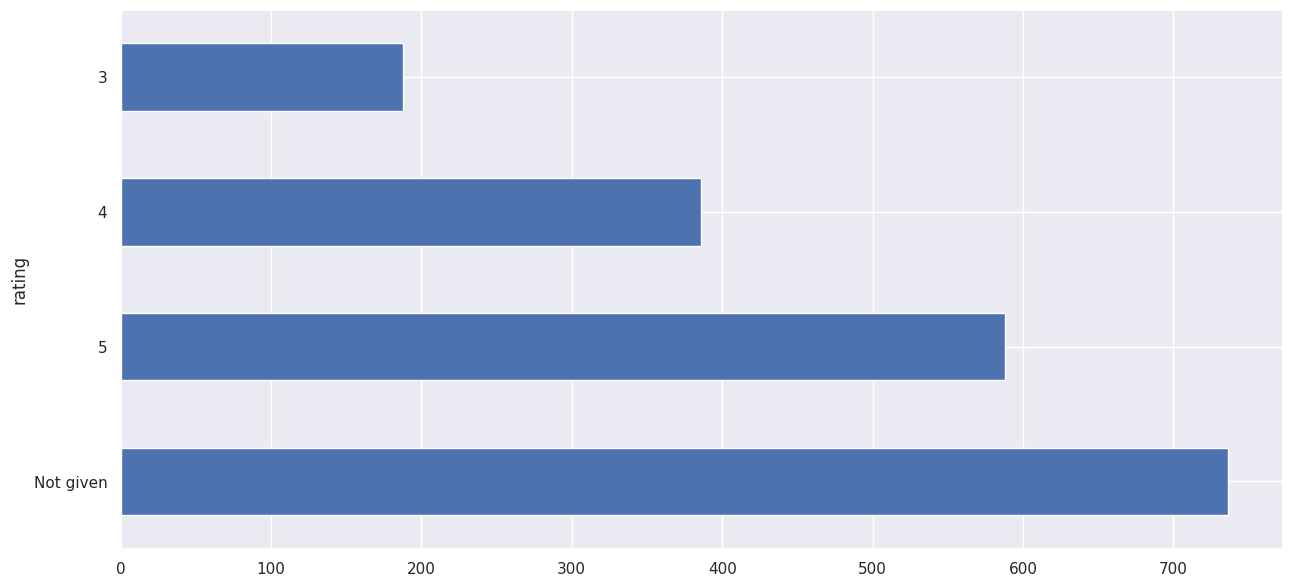

In [58]:
# Write the code here
print(72 * "*")
print(data['rating'].value_counts())
print(72 * "*")
print(f"Bar chart for column rating in data frame:")
print(72 * "*")
data['rating'].value_counts().plot(kind='barh');

#### Observations: 736 order are not given a rating. For ratings some customers choose not to give ratings and this is implemented by using term "Not given" in lieu of a numeric rating. The remaining 1162 orders were rating 3-5. 5 being the most rate given by customers and 3 being the lowest rate given by customers.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

the number of unique orders 1898
the number of unique customers 1200


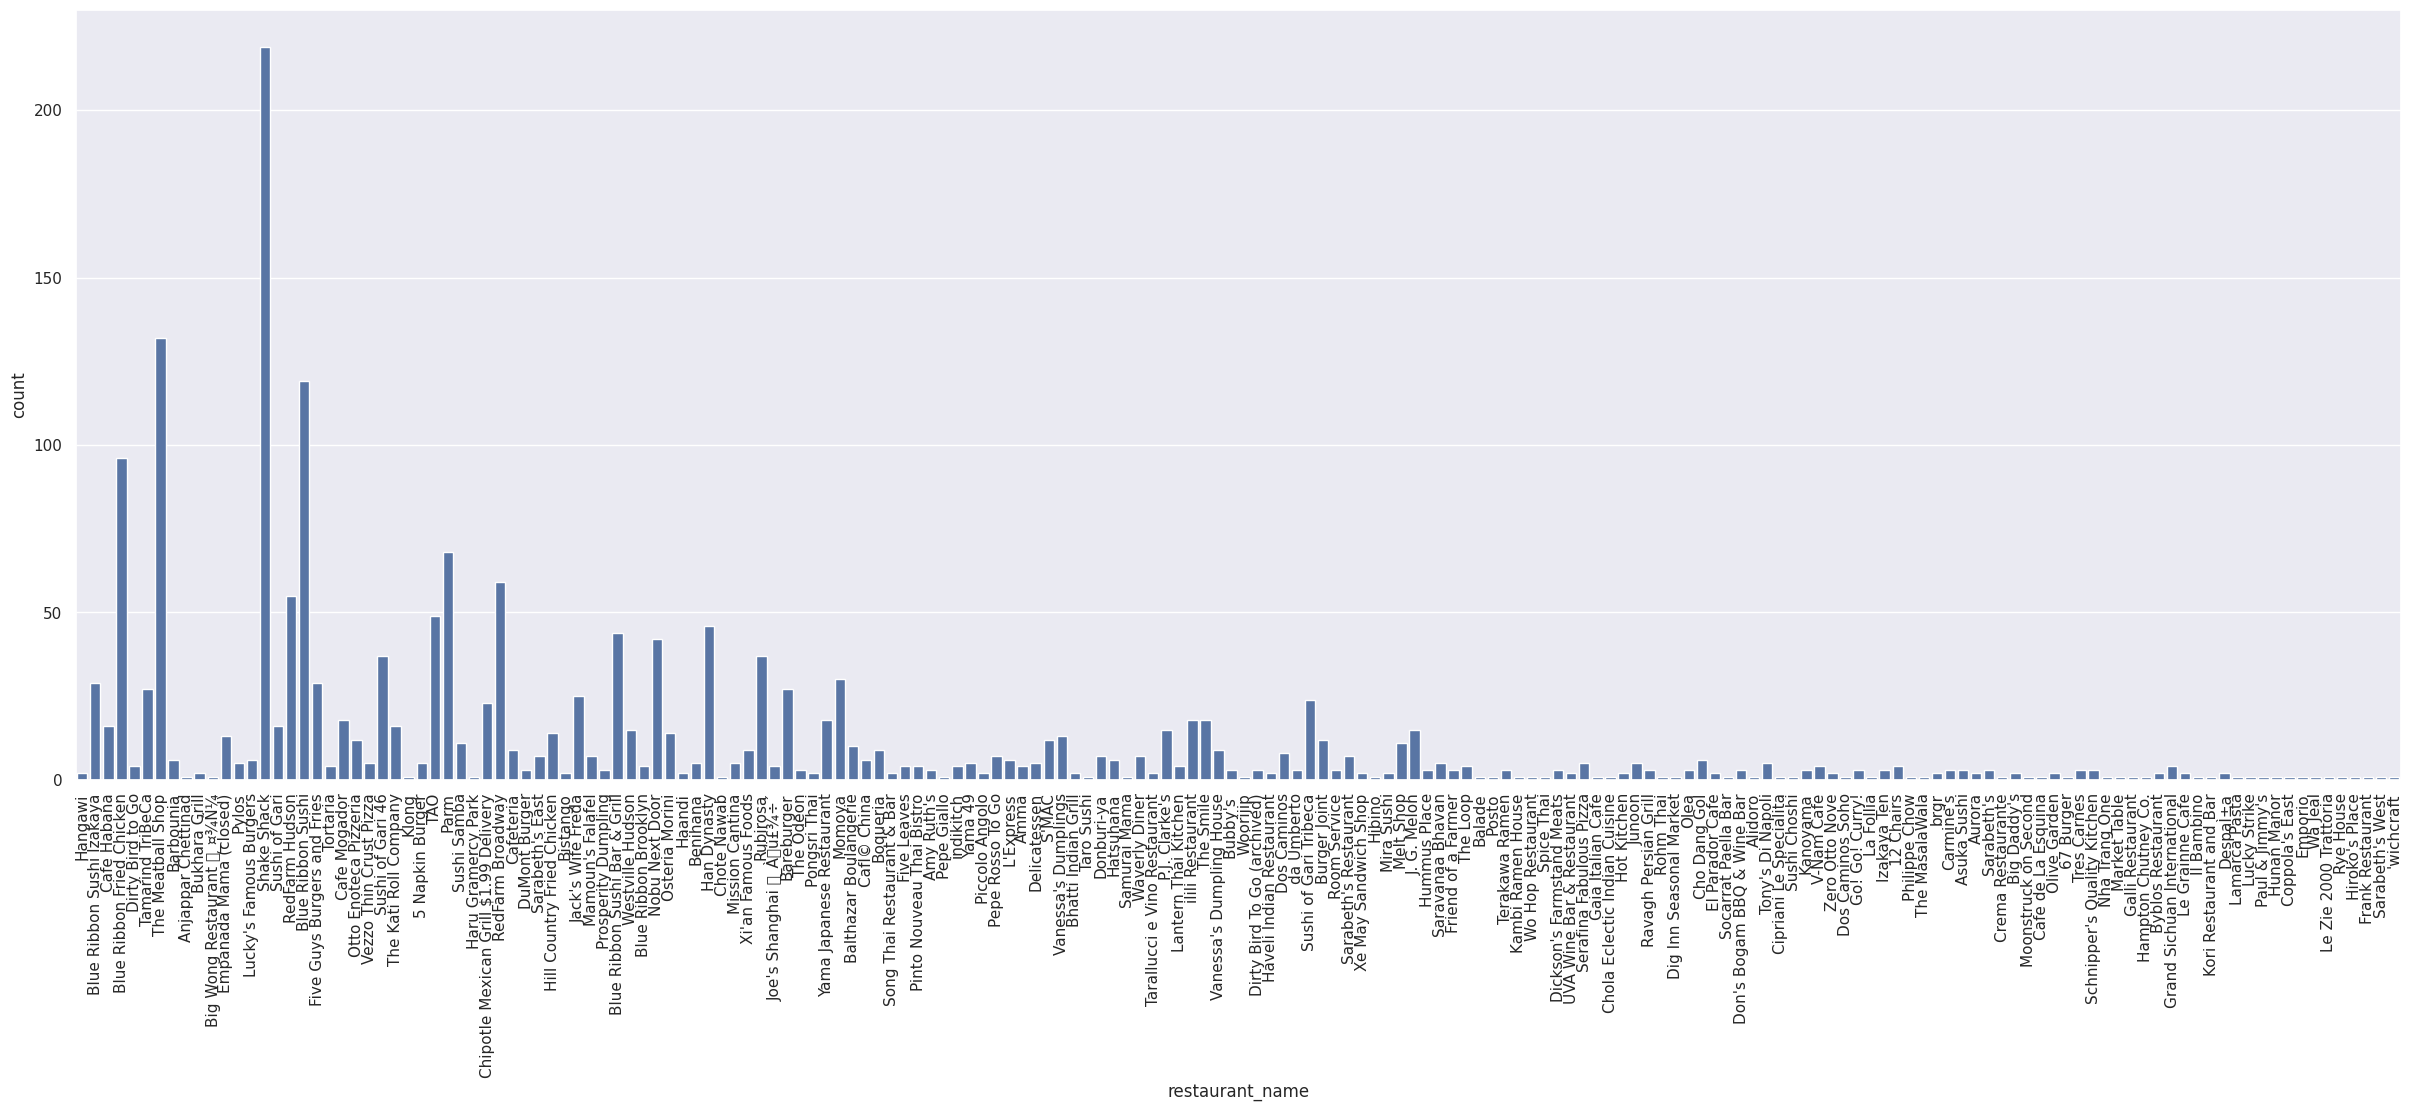

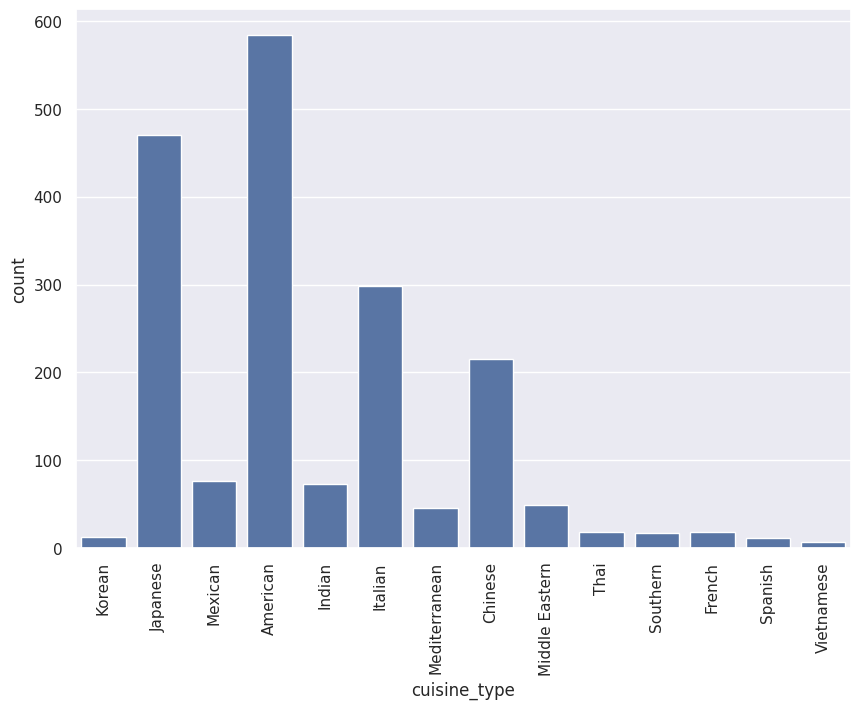

<Figure size 1500x700 with 0 Axes>

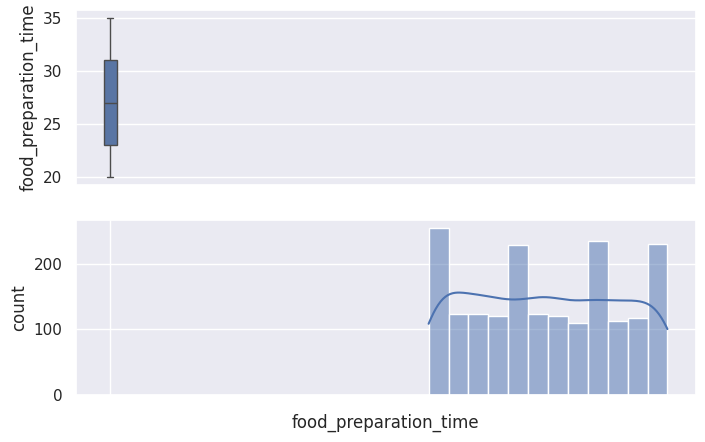

<Figure size 800x500 with 0 Axes>

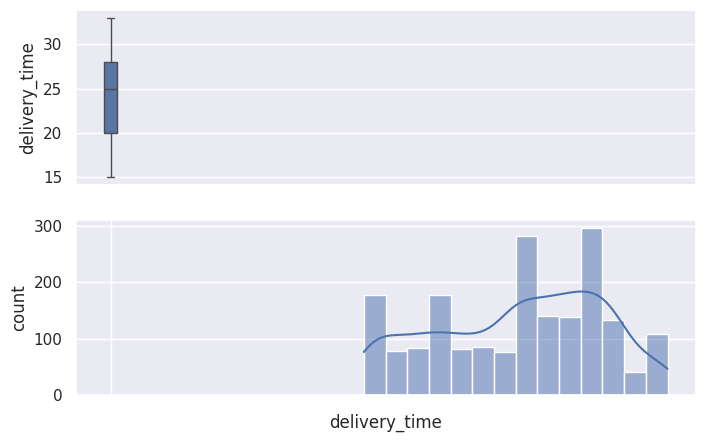

<Figure size 800x500 with 0 Axes>

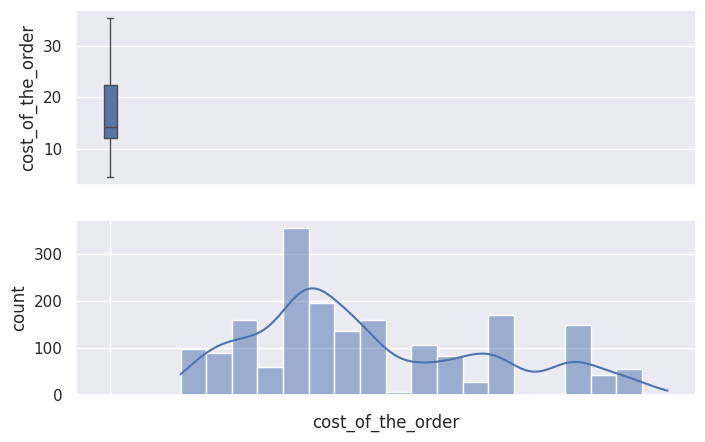

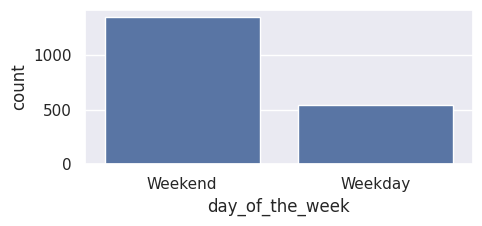

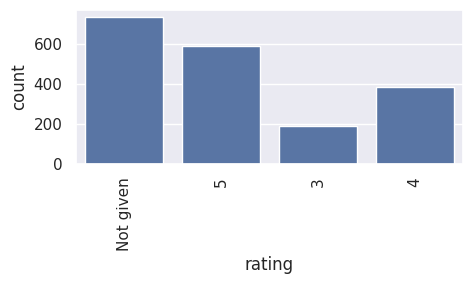

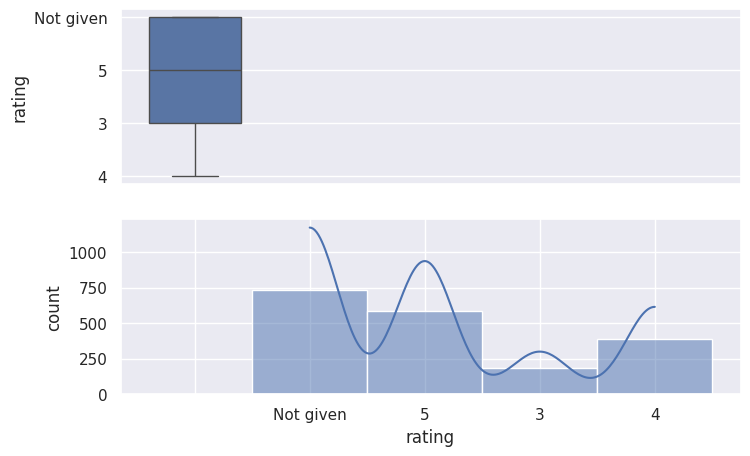

In [59]:
# Write the code here
# order id
# check the count of unique number of order id, value counts
order_unique = data['order_id'].nunique()
print(f'the number of unique orders', order_unique)
# customer id
# check the count of unique number of order id, value counts
customer_unique = data['customer_id'].nunique()
print(f'the number of unique customers', customer_unique)
# restaurant name
# check the count of unique number of restaurant name, value counts, countplot
data['restaurant_name'].nunique()
restaurant_name_counts = data["restaurant_name"].value_counts
restaurant_name_counts()
plt.figure(figsize=(30,10))
sns.countplot(data, x='restaurant_name')
plt.xticks(rotation=90);
plt.show()
# cuisine type
# check the count of unique number of cuisine type, value counts, and countplot.
data['cuisine_type'].nunique()
cuisine_type_counts = data["cuisine_type"].value_counts
cuisine_type_counts()
plt.figure(figsize=(10,7))
sns.countplot(data, x='cuisine_type')
plt.xticks(rotation=90);
# food_preparation_time
# boxplot and histplot.
i = "food_preparation_time"
plt.figure()
plt.tight_layout()
sns.set(rc={"figure.figsize":(8, 5)})
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True)
plt.gca().set(xlabel= i,ylabel='count')
sns.boxplot(data[i], ax=ax_box , linewidth= 1.0);
sns.histplot(data[i], ax=ax_hist , kde=True);
# delivery_time
# boxplot and histplot.
i = "delivery_time"
plt.figure()
plt.tight_layout()
sns.set(rc={"figure.figsize":(8, 5)})
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True)
plt.gca().set(xlabel= i,ylabel='count')
sns.boxplot(data[i], ax=ax_box , linewidth= 1.0);
sns.histplot(data[i], ax=ax_hist , kde=True);
# cost_of_the_order
# boxplot and histplot.
i = "cost_of_the_order"
plt.figure()
plt.tight_layout()
sns.set(rc={"figure.figsize":(8, 5)})
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True)
plt.gca().set(xlabel= i,ylabel='count')
sns.boxplot(data[i], ax=ax_box , linewidth= 1.0);
sns.histplot(data[i], ax=ax_hist , kde=True);
# day_of_the_week
# check the count of unique number of Days of the week, and countplot.
data['day_of_the_week'].nunique()
plt.figure(figsize = (5,2))
sns.countplot(data, x = 'day_of_the_week')
# rating
# check the count of unique number of rating, value_counts, countplot, boxplot and histplot.
i = "rating"
data['rating'].nunique()
rating_counts = data["rating"].value_counts()
plt.figure(figsize=(5,2))
sns.countplot(data, x='rating');
plt.xticks(rotation=90);
sns.set(rc={"figure.figsize":(8, 5)})
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True)
plt.gca().set(xlabel= i,ylabel='count')
sns.boxplot(data[i], ax=ax_box , linewidth= 1.0);
sns.histplot(data[i], ax=ax_hist , kde=True);



# ### Exploratory Data Analysis (EDA)


# ### Univariate Analysis


# **Observation:**

Cost of Orders
The Cost of orders is bi-modal and there is a amrket segmentaiton of an upscale marker and lower scale market. The histplot is skewed to the left, that is,more towards lower costs, however we note that there is a peak at around 25 dollars. The boxplot indicates that the median cost is about 14 dollars, with the orders being right skewed. This implies a a bigger spread above the median. Given that we have two main target markets;  one lower class market segment possibly students and blue collar workers, and one working white-collar professionals,

Cuisine Type:
The most popular cuisines are American, Japanese,Italian,Chinese in that order, followed by Mexican and Indian.

Rating:
For the rated orders,considering that there are about 38.77% unrated orders, the histplot shows that the ratings are concentrated around the maximum rating, but the boxplot is heavily skewed to the left.

Day of Week:
There is higher activity over the weekend than during the other weekdays.

Food preparation time:
There is a fairly even distribution of the time it takes to prepare the dish between 20 minutes and 36 minutes with a median of about 27 minutes.

Delivery Time:
The median delivery time is about 25 minutes with the observations being skewed to the left. From the histplot we can determine that most orders take between 25 and 28 minutes to be delivered.



### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

********************************************************************************
Print the value counts for all in ascending order for:  restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64
********************************************************************************
Print a chart of top 5 restaurants in terms of the number of orders received:
********************************************************************************


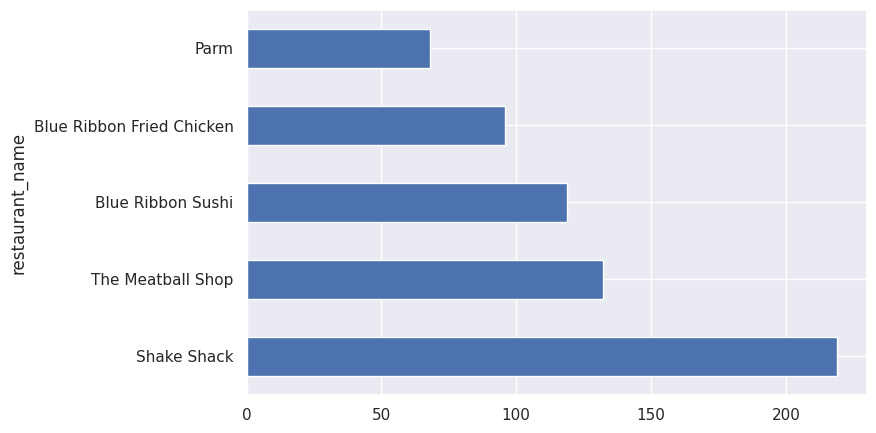

In [60]:
# Write the code here
print(80 * "*")
print(f'Print the value counts for all in ascending order for: ',data['restaurant_name'].value_counts().iloc[:5])
print(80 * "*")
print(f'Print a chart of top 5 restaurants in terms of the number of orders received:')
print(80 * "*")
#find values with top 5 occurrences store in top_5_restaurants
#top_5_restaurants = (data['restaurant_name'].value_counts()).iloc[:5]
top_5_using_head = (data['restaurant_name'].value_counts()).head(5)
#create bar chart to visualize top 5 occurrence
#top_5_restaurants.plot(kind='barh');
top_5_using_head.plot(kind='barh');

####Observation:
#####5 Most Popular Restaurants in FoodHub - Shake Shack is the most popular restaurant in FoodHub with 219 orders, followed by The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Sushi and Parm in that order. These restaurants may offer higher quality cuisine, have better customer service and customer satisfaction, and they may offer coupons or promotions.
####Quality Validation for restaurants - FoodHub might want to validate why some restaurants are receiving few orders. It could be due to poor customer service, lower quality food ingredients, cuisine type, pricing model, poor customer service, or slow delivery time. Foodhub may decide that they build partnerships with more popular brand restaurants while helping less popular restaurants via promotions and coupons.



### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

************************************************************************
cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: count, dtype: int64
************************************************************************
Bar chart for column rating in data frame:
************************************************************************


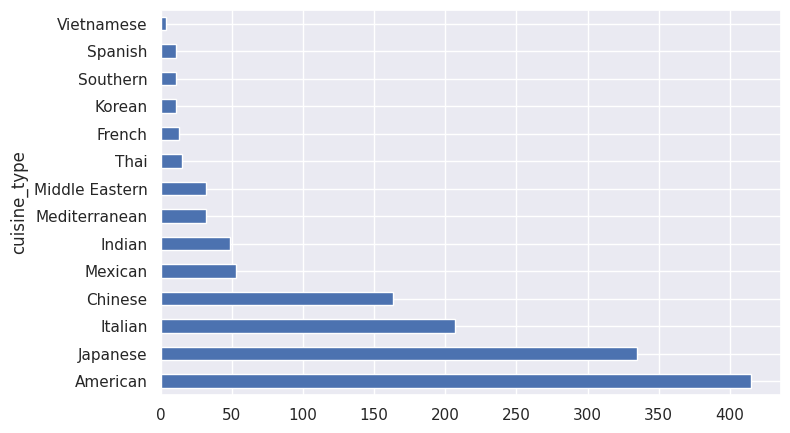

In [61]:
# Write the code here
print(72 * "*")
print(data['cuisine_type'].value_counts())
print(72 * "*")
print(f"Bar chart for column rating in data frame:")
print(72 * "*")
# data['cuisine_type'].value_counts().plot(kind='barh');
df_weekend = data[data['day_of_the_week'] == 'Weekend']
cuisine_counts_weekend = df_weekend['cuisine_type'].value_counts()
cuisine_counts_weekend.plot(kind='barh');

#### Observations: American food is most popular on weekends in FoodHub with 584 meals, followed by Japanese with 470, Italian with 298, Chinese with 217 and Mexican with 77.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [63]:
# Write the code here
data_order_more_than_twenty = data[data['cost_of_the_order']>20]
total_orders = data.shape[0]
total_orders_over_twenty = data_order_more_than_twenty.shape[0]
print(f'The total number of orders in FoodHub is:', total_orders)
print(f'The total number of orders in FoodHub that cost more than 20 dollars is:', total_orders_over_twenty)
percentage_over_twenty = (total_orders_over_twenty / total_orders) * 100
print(f'The percentage of orders that cost more than 20 dollars is:', round(percentage_over_twenty, 2), f'%')

The total number of orders in FoodHub is: 1898
The total number of orders in FoodHub that cost more than 20 dollars is: 555
The percentage of orders that cost more than 20 dollars is: 29.24 %


#### Observations:
The total number of orders in FoodHub is: 1898. The total number of orders in FoodHub that cost more than 20 dollars is: 555. The percentage of orders that cost more than 20 dollars is 29.24 %

### **Question 10**: What is the mean order delivery time? [1 mark]

In [64]:
# Write the code here
mean_delivery_time = data['delivery_time'].mean()
print(f'The mean order delivery time is for all orders in Foodhub:', round(mean_delivery_time, 2), f'minutes')

The mean order delivery time is for all orders in Foodhub: 24.16 minutes


#### Observations: The mean order delivery time is for all orders in Foodhub is 24.16 minutes


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [65]:
# Write the code here
top_three_frequent_customers = data['customer_id'].value_counts().head(3)
print(f'The top three most frequent customers and there order counts: ', top_three_frequent_customers)

The top three most frequent customers and there order counts:  customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


#### Observations:  The top three most frequent customers and there order counts are customer number  52832 with 13 orders, customer number 474440 with 10 orders, and customer number 832887 with 9 orders.


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


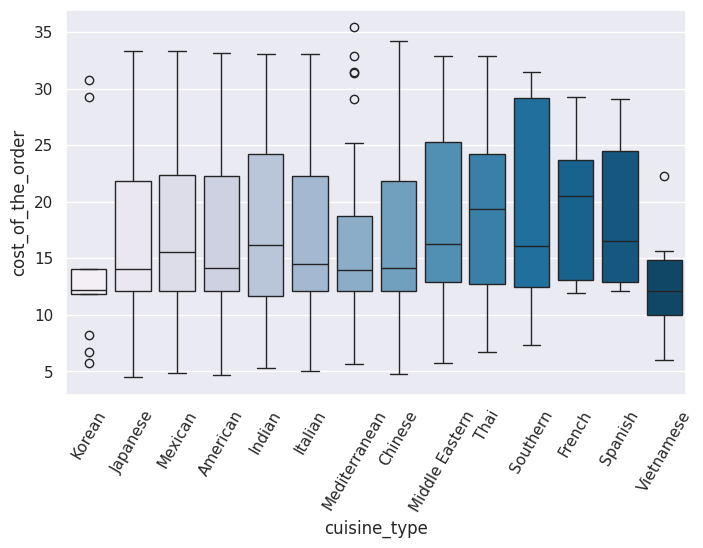

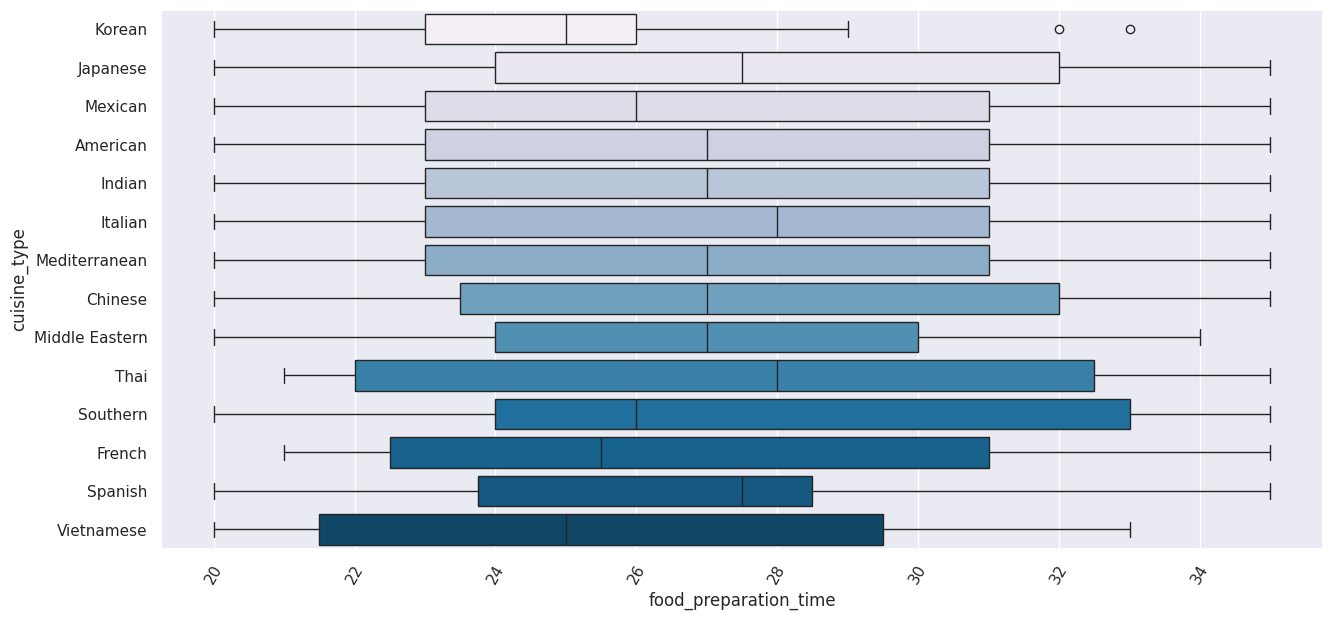

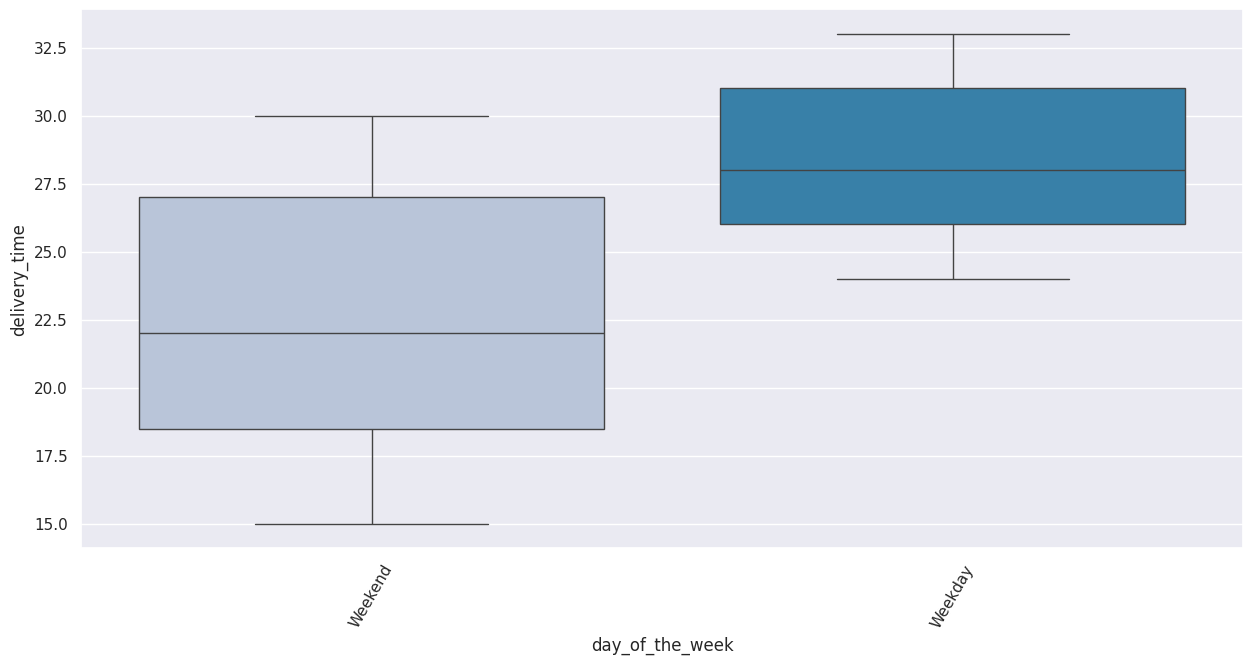

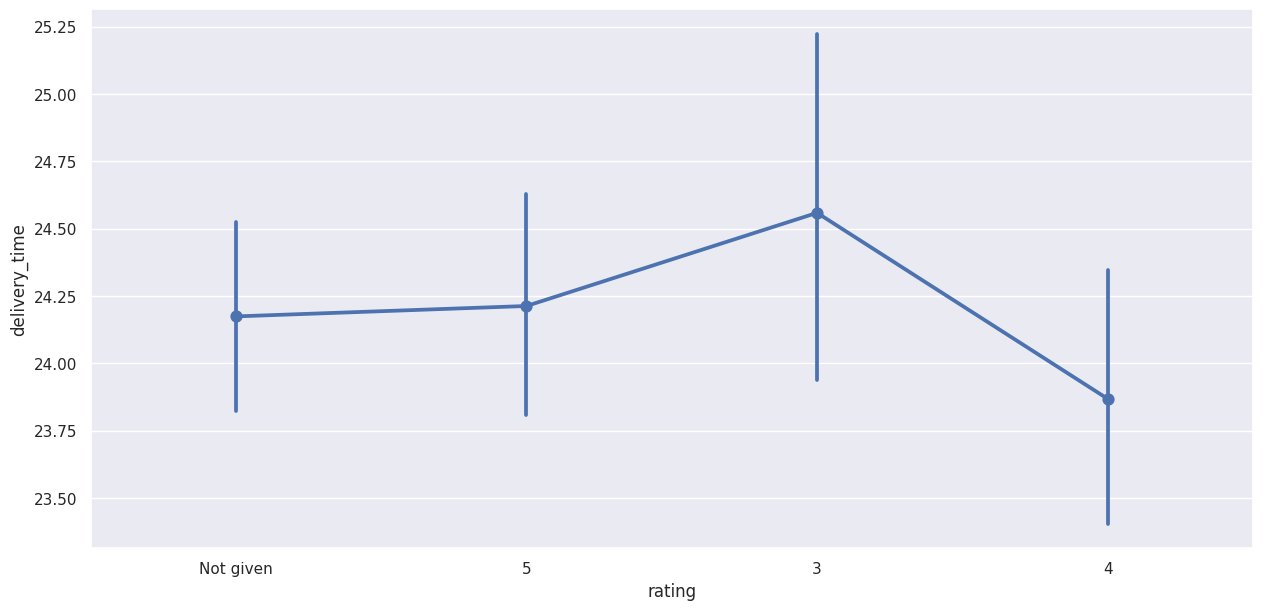

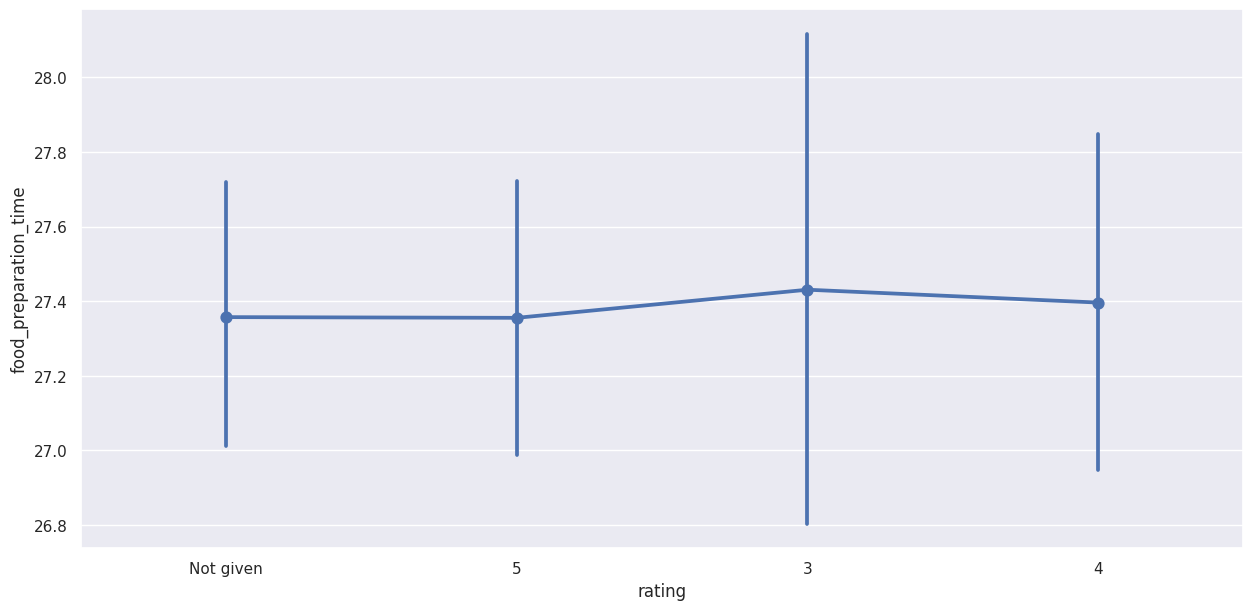

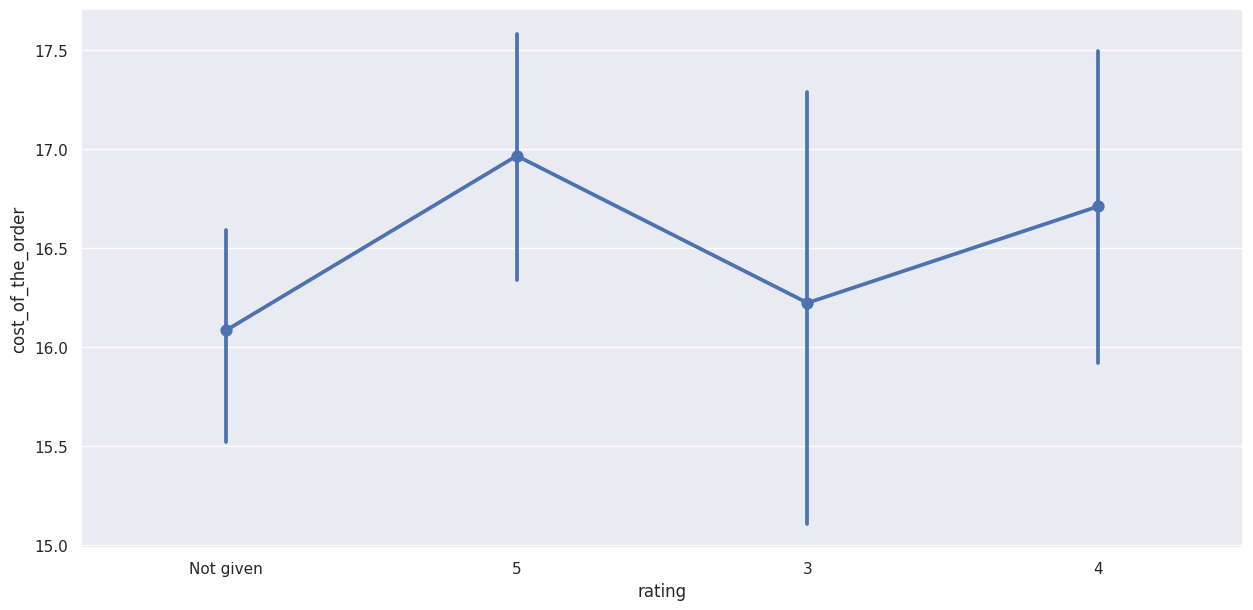

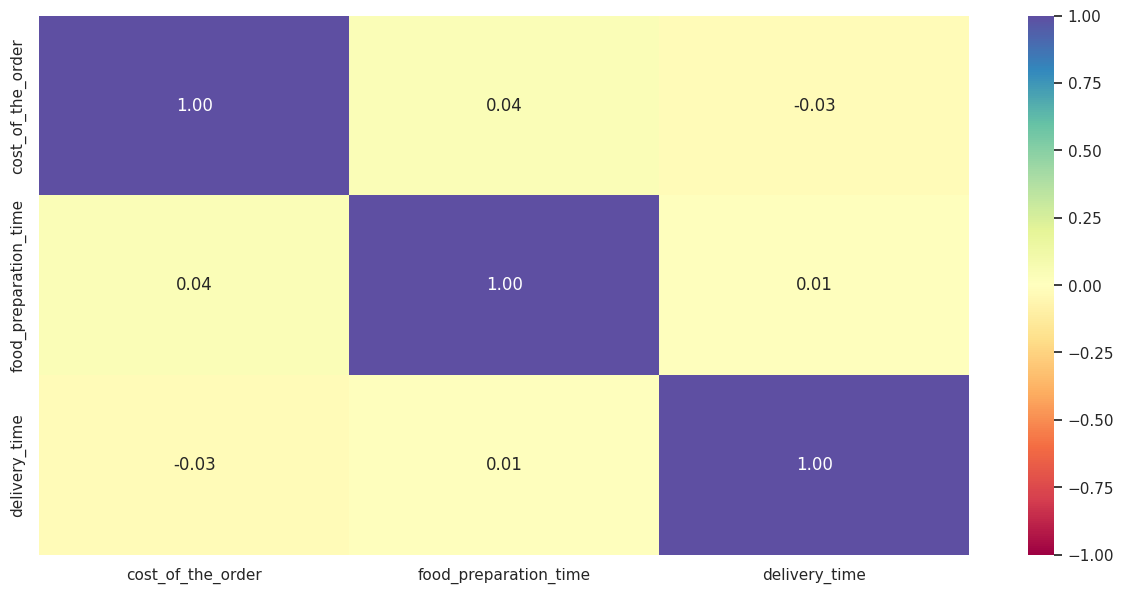

In [66]:
# Write the code here
# relationship between cuisine_type and cost_of_order
xfield = "cuisine_type"
yfield = "cost_of_the_order"
plt.figure()
plt.tight_layout()
sns.set(rc={"figure.figsize":(15, 7)})
sns.boxplot(data, x = xfield, y = yfield,  palette = 'PuBu')
plt.xticks(rotation = 60)
plt.show();
# relationship between food_preparation_time and cuisine_type
xfield = "food_preparation_time"
yfield = "cuisine_type"
plt.figure()
plt.tight_layout()
sns.set(rc={"figure.figsize":(15, 7)})
sns.boxplot(data, x = xfield, y = yfield,  palette = 'PuBu')
plt.xticks(rotation = 60)
plt.show();
# relationship between day_of_the_week and delivery_time
xfield = 'day_of_the_week'
yfield = 'delivery_time'
plt.figure()
plt.tight_layout()
sns.set(rc={"figure.figsize":(15, 7)})
sns.boxplot(data, x = xfield, y = yfield,  palette = 'PuBu')
plt.xticks(rotation = 60)
plt.show();
# relationship between rating and delivery_time
xfield = 'rating'
yfield = 'delivery_time'
plt.figure(figsize=(15, 7))
sns.pointplot(data, x = xfield, y = yfield)
plt.show();
# relationship between rating and food_preparation_time
xfield = 'rating'
yfield = 'food_preparation_time'
plt.figure(figsize=(15, 7))
sns.pointplot(data, x = xfield, y = yfield)
plt.show()
# relationship between rating and cost_of_the_order
xfield = 'rating'
yfield = 'cost_of_the_order'
plt.figure(figsize=(15, 7))
sns.pointplot(data, x = xfield, y = yfield)
plt.show();
# correlation between all variables - heatmap
col_list = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
plt.figure(figsize=(15, 7))
sns.heatmap(data[col_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show();

####Observations:

Cost of Order/Rating: its seems the most costly orders are rated higher then less costly

Cost of order and Delivery Preparation time - it seems that orders with larger deliveyr and prepartion times have lower ratings

Orders per cuisine per day of the week:
The most popular cuisine folllow the same pattern irrespective of the day of the week.

Day of the week against the other variables:
Delivery time which generally takes longer during the weekdays than during the weekends. The median delivery time for weekends is around 22.5 minutes while that of the weekdays is about 28.5 minutes

Spread Cost of Order:
Most cuisines have varying degrees of skewed costs with a few having outliers such as Korean, Mediterranean and Vietnamese

Heatmap and pairplot:
The heatmap shows very weak correlation between the variables.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [67]:
# Write the code here
df_rated = data[data['rating'] != 'Not given'].copy()
df_rated['rating'] = df_rated['rating'].astype('int')
df_rating_count = df_rated.groupby(['restaurant_name'])['rating'].count().sort_values(ascending = False).reset_index()
df_rating_count.head()
rest_names = df_rating_count[df_rating_count['rating'] > 50]['restaurant_name']
df_mean_4 = df_rated[df_rated['restaurant_name'].isin(rest_names)].copy()
df_mean_4.groupby(['restaurant_name'])['rating'].mean().sort_values(ascending = False).reset_index().dropna()

,restaurant_name,rating
0,The Meatball Shop,4.511905
1,Blue Ribbon Fried Chicken,4.328125
2,Shake Shack,4.278195
3,Blue Ribbon Sushi,4.219178


#### Observations:
The top restaurants with at least 50 rating count and average rating greater than 4 are The Meatball Shop with rating of 4.511905, Blue Ribbon Fried Chicken with rating of 4.328125, Shake Shack	with rating of 4.278195, Blue Ribbon Sushi with rating of 4.219178.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [68]:
# Write the code here
def net_revenue(cost):
  if cost > 20:
    return cost*0.25
  elif cost > 5:
    return cost*0.15
  else:
    return cost*0


data['Revenue'] = data['cost_of_the_order'].apply(net_revenue)
total_rev = data['Revenue'].sum()
print('The net revenue is around', round(total_rev, 2), 'dollars')

The net revenue is around 6166.3 dollars


#### Observations:


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [69]:
# Write the code here
data['total_time'] = data['food_preparation_time'] + data['delivery_time']
df_greater_than_60 = data[data['total_time']>60]
print(f'The total number of delivery orders more than 60 minutes:', df_greater_than_60.shape[0])
percentage = (df_greater_than_60.shape[0] / data.shape[0]) * 100
print(f'The percentage of delivery orders more than 60 minutes:', round(percentage, 2), f'%')


The total number of delivery orders more than 60 minutes: 200
The percentage of delivery orders more than 60 minutes: 10.54 %


#### Observations:
The total number of orders that took more than 60 minutes to get delivered is 200. Percentage of orders that took more than 60 minutes to get delivered is 10.54 %

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [70]:
# Write the code here
print(f'The mean delivery time on weekends is around',
      round(data[data['day_of_the_week'] == 'Weekend']['delivery_time'].mean()),
     'minutes.')
print(f'The mean delivery time on weekdays is around',
      round(data[data['day_of_the_week'] == 'Weekday']['delivery_time'].mean()),
     'minutes.')


The mean delivery time on weekends is around 22 minutes.
The mean delivery time on weekdays is around 28 minutes.


#### Observations: The mean delivery time on weekends is around 22 minutes. The mean delivery time on weekdays is around 28 minutes.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]


# **Observation:**
The bimodal peak on the cost of orders processed may imply a differenciated market segment. There are not enough ratings. Order time could be increased. Weekday sales could be increased. There is an opportunioty for promotions to increase sales.




### Recommendations:
Based on the observations in this analysis below is recommended.

####Market segmentation:
The bimodal peak on the cost of FoodHub orders processed may be two differentiated market segments. It is possible the first peak at 15 dollars has a higher concentration of blue collar workers or students with the second peak at 25 dollars having a higher concentration of the more affluent white-collar professionals. We would need gather and perform an analysis of the customer demographics to better understand this.
####Increase the number of ratings:
FoodHub needs to encourage more ratings of orders. It may be possible to reward customers with discounts, points or other rewards to give ratings. The ratings provide better data to determine customer satisfaction and enable service improvements.
####Improve total order time:
Foodhub needs to improve on total order time to improve ratings. It seems slow total order time may be the cause of low orders and lower ratings during the weekdays. Also traffic patterns on weekdays could be the cause of the higher delivery time on weekdays.
####Provide promotions:
Development of a reward or discount program that is practical and increases order while still maintaining profits and revenues should be a goal.
####Increase weekday sales:
Better marketing can be focused on the weekday to boost sales.







---